<a href="https://colab.research.google.com/github/rizanatlanta-dsproj/Spam-Email-Detection/blob/main/Spamdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Spam Detection Project
# Dataset Recommended by: Supervisor Sk Asrafuzzaman (Head lecturer, Ict)


Week 1: Research, Dataset Collection, Dataset Preprocessing

In [12]:
#Importing Libraries

In [13]:
!pip install xgboost dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.2 MB/s eta 0:00:00


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay



In [16]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore")


In [19]:
!pip install opendatasets

In [20]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rizanatlanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset


100%|██████████| 2.86M/2.86M [00:00<00:00, 394MB/s]

In [21]:
import pandas as pd
data = pd.read_csv('/content/spam-email-dataset/emails.csv')

In [22]:
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [24]:
data.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [26]:
print(data.shape)

(5728, 2)


In [27]:
data.drop_duplicates(inplace=True)
print(data.shape)

(5695, 2)


In [28]:
print(data.isnull().sum())

text    0
spam    0
dtype: int64


In [29]:
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [32]:
data['Category'] = data['spam'].replace([1, 0], ['Spam', 'Not Spam'])

In [33]:
data.head()

,text,spam,Category
0,Subject: naturally irresistible your corporate...,1,Spam
1,Subject: the stock trading gunslinger fanny i...,1,Spam
2,Subject: unbelievable new homes made easy im ...,1,Spam
3,Subject: 4 color printing special request add...,1,Spam
4,"Subject: do not have money , get software cds ...",1,Spam


In [34]:
data.tail()

,text,spam,Category
5723,Subject: re : research and development charges...,0,Not Spam
5724,"Subject: re : receipts from visit jim , than...",0,Not Spam
5725,Subject: re : enron case study update wow ! a...,0,Not Spam
5726,"Subject: re : interest david , please , call...",0,Not Spam
5727,Subject: news : aurora 5 . 2 update aurora ve...,0,Not Spam


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5695 entries, 0 to 5727
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      5695 non-null   object
 1   spam      5695 non-null   int64 
 2   Category  5695 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.0+ KB


<Axes: >

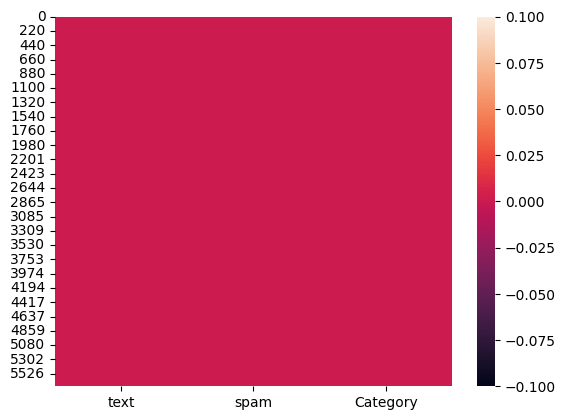

In [37]:
sns.heatmap(data.isnull())

In [39]:
data = data.iloc[:, 1:]

In [40]:
data

,Category
0,Spam
1,Spam
2,Spam
3,Spam
4,Spam
...,...
5723,Not Spam
5724,Not Spam
5725,Not Spam
5726,Not Spam


In [45]:
data.nunique()

,0
Category,2


<Axes: xlabel='Category', ylabel='count'>

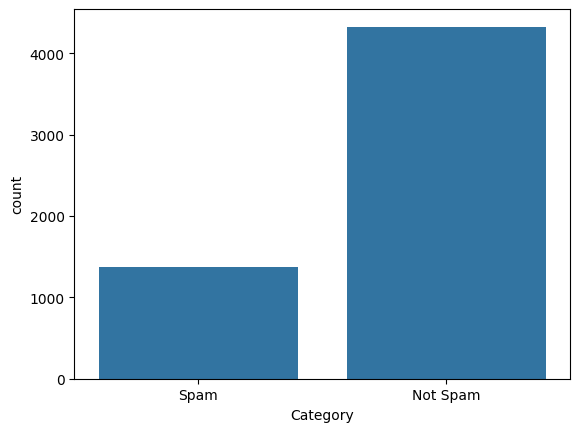

In [46]:
sns.countplot(x='Category', data=data)

In [51]:
x= data.iloc[:,:3000].values
x

array([['Spam'],
       ['Spam'],
       ['Spam'],
       ...,
       ['Not Spam'],
       ['Not Spam'],
       ['Not Spam']], dtype=object)

In [52]:
y = data.iloc[:, -1].values
y

array(['Spam', 'Spam', 'Spam', ..., 'Not Spam', 'Not Spam', 'Not Spam'],
      dtype=object)

Train and Test Splitting the data

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

Performance Measurement and Showing Matrix

In [54]:
def perform(y_pred):
    print("Precision : ", precision_score(y_test, y_pred))
    print("Recall : ", recall_score(y_test, y_pred))
    print("Accuracy Score : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", f1_score(y_test, y_pred))
    print("\n", confusion_matrix(y_test, y_pred))
    print("")

    cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred), display_labels=['Spam', 'Not Spam'] )
    cm_display.plot()
    plt.show()
